## make_sbc:
### Make surface boundary conditions.
#### Version id:
#### v1.
#### Tamura fluxes and ERA_interim

In [1]:
cd /g/data/jk72/deg581/amundsen-isom/amundsen-setup/notebooks

/g/data/jk72/deg581/amundsen-isom/amundsen-setup/notebooks


In [2]:
run ='amundsen_2.5km'

import numpy as np 
import os
import sys
import xarray as xr
import scipy.io as sio
import matplotlib.pyplot as plt
import datetime
from scipy.interpolate import griddata
from scipy.signal import convolve2d


proj_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
data_dir = os.path.join(proj_dir,'data')
src_dir = os.path.join(proj_dir,'src')

sys.path.append(src_dir)


from ext.tools.NDinterp import NDinterp
from ext.tools.log_progress import log_progress


# Time settings for IAF
year_start =  1992
year_end = 2017 # run from year_start up to the beginning of year year_end

# set paths

import socket
comp_name = socket.gethostname()
if comp_name=='SEES-3PV4VV3':
    T_mask_path = os.path.join(data_dir,'raw','tamura','EASE_landmask_H.data')
    T_lat_lon_path = os.path.join(data_dir,'raw','tamura','EASE_latlon_H.data')
    T_data_path = os.path.join(data_dir,'raw','tamura')
    era_path = os.path.join(data_dir,'raw','era_interim','ERA_Interim_1992_2011.2daily.*winds.nc')
    R_grid_path = os.path.join(data_dir,'proc',run+'_v11_grd.nc')
else:
    data_dir_ext = '/g/data/jk72/iomp/obs/'
    T_mask_path = os.path.join(data_dir_ext,'Tamura_daily','EASE_landmask_H.data')
    T_lat_lon_path = os.path.join(data_dir_ext,'Tamura_daily','EASE_latlon_H.data')
    T_data_path = os.path.join(data_dir_ext,'Tamura_daily')
    # era_path = os.path.join(data_dir_ext,'raw','era_interim','ERA_Interim_1992_2011.2daily.*winds.nc')
    era_path = os.path.join(data_dir_ext,'era_interim','ERA_5_1988_2025.daily.10mWinds.nc')    
    R_grid_path = os.path.join(data_dir,'proc',run+'_v1_grd.nc')

In [3]:
def tic():
    #Homemade version of matlab tic and toc functions
    import time
    global startTime_for_tictoc
    startTime_for_tictoc = time.time()

def toc():
    import time
    if 'startTime_for_tictoc' in globals():
        print("Elapsed time is " + str(time.time() - startTime_for_tictoc) + " seconds.")
    else:
        print("Toc: start time not set")


In [40]:
#load roms grid and convert lon to 0-360

R_grid = xr.open_dataset(R_grid_path)
R_lon = R_grid.lon_rho.values
R_lat = R_grid.lat_rho.values
R_angle = R_grid.angle.values
R_ulon = R_grid.lon_u.values
R_vlon = R_grid.lon_v.values
R_ulat = R_grid.lat_u.values
R_vlat = R_grid.lat_v.values


R_lon[R_lon<0]+=360 # This command updates lon_rho in the grid ds.
R_ulon[R_ulon<0]+=360
R_vlon[R_vlon<0]+=360

In [25]:
#read in tamura land mask
with open(T_mask_path,'rb') as fid:
    T_mask = np.fromfile(fid,count=(721*721),dtype='float32').reshape((721,721))
    T_mask = np.flipud(T_mask)

In [26]:
#get tamura lat lon coordinates
with open(T_lat_lon_path,'rb') as fid:
    T_lat_lon = np.fromfile(fid,count=(721*721*2),dtype='float32').reshape((2,721,721))
T_lat,T_lon = (T_lat_lon[0],T_lat_lon[1])
T_lat = np.flipud(T_lat)
T_lon = np.flipud(T_lon)
T_lon[T_lon<0]+=360



/jobfs/166449804.gadi-pbs/ipykernel_458916/4074133793.py:1: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(T_lon,T_lat,T_mask)


(721, 721)
(721, 721)


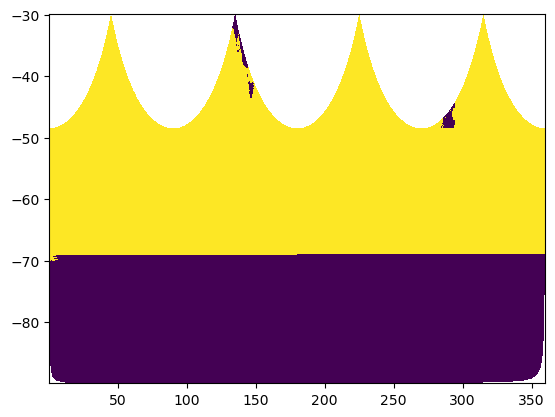

In [27]:
plt.pcolormesh(T_lon,T_lat,T_mask)
print(T_mask.shape)
print(T_lon.shape)


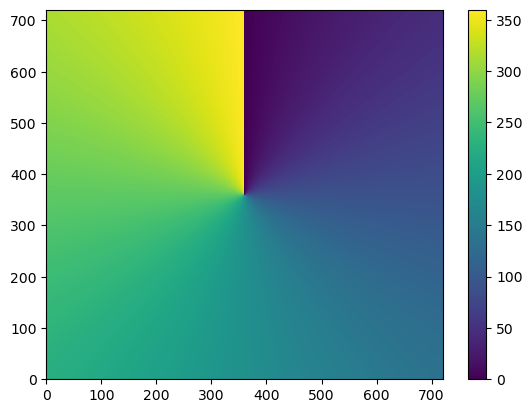

In [31]:
plt.pcolormesh(T_lon)
plt.colorbar()

In [56]:
T_boundary_mask=(
    (T_lon > R_grid.lon_rho.min().values*0.95) & 
    (T_lon < R_grid.lon_rho.max().values*1.05) &
    (T_lat > R_grid.lat_rho.min().values*1.05) &
    (T_lat < R_grid.lat_rho.max().values*0.95))

# Find indices where mask is True
indices = np.argwhere(T_boundary_mask)

# Get bounding box: min/max along each axis
i_min, j_min = indices.min(axis=0)
i_max, j_max = indices.max(axis=0)

T_lon_subset = T_lon[i_min:i_max+1, j_min:j_max+1]
T_lat_subset = T_lat[i_min:i_max+1, j_min:j_max+1]

#So extract only:
print('from ROMS grid, lon/lat max/min:')
print(str(R_grid.lon_rho.min().values*0.98), str(R_grid.lon_rho.max().values*1.02), str(R_grid.lat_rho.min().values*1.02), str(R_grid.lat_rho.max().values*0.98))
print('extracting:')
print(T_lon_subset.min(),T_lon_subset.max(),T_lat_subset.min(),T_lat_subset.max())
print('new subset size:')
print(T_lon_subset.shape)
# T_lat_subset
# T_loni_min, i_max, j_min,j_max

from ROMS grid, lon/lat max/min:
215.551000017921 275.45100001199154 -77.6092499916874 -67.53424998842766
extracting:
193.17256 318.65222 -85.039 -57.369118
new subset size:
(239, 172)


In [58]:
# subset T_values

T_mask = T_mask[i_min:i_max+1, j_min:j_max+1]


T_lon = T_lon[i_min:i_max+1, j_min:j_max+1]
T_lat = T_lat[i_min:i_max+1, j_min:j_max+1]



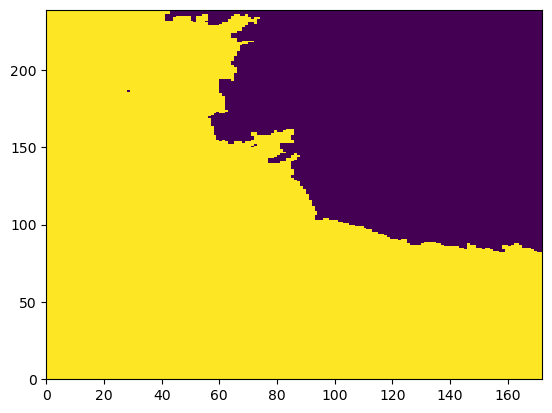

(239, 172)
(239, 172)


/jobfs/166449804.gadi-pbs/ipykernel_458916/2929046047.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(T_lon,T_lat,T_mask)


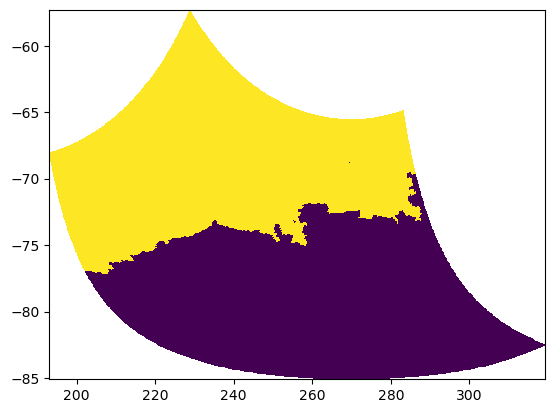

In [10]:
plt.pcolormesh(T_mask)
plt.show()
plt.pcolormesh(T_lon,T_lat,T_mask)
print(T_mask.shape)
print(T_lon.shape)


In [112]:
#read in era interim winds and resample from twice daily to daily
# era_ds = xr.open_mfdataset(era_path,data_vars='minimal').sel(time='2007',latitude=slice(-30,-90)).resample(time='D').mean() # don't need to convert 2-daily->daily
era_ds = xr.open_mfdataset(era_path,data_vars='minimal')

era_ds['longitude'] = era_ds.longitude % 360 # Have to update the era longitude variable so it also runs 0 ... 360.


# subset ERA data
era_ds = era_ds.sel(longitude=slice((R_grid.lon_rho.min().values*.95).round(),(R_grid.lon_rho.max().values*1.05).round())).sel(
    latitude=slice(R_grid.lat_rho.max().values*0.95,R_grid.lat_rho.min().values*1.05)).sel(
    valid_time=slice(str(year_start)+'-01-01',str(year_end)+'-01-01'))

#get era coordinates
era_lon,era_lat = era_ds.longitude.values,era_ds.latitude.values
era_lon_2d,era_lat_2d = np.meshgrid(era_lon,era_lat)

In [113]:
era_ds

<xarray.Dataset>
Dimensions:     (valid_time: 9133, latitude: 58, longitude: 301)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 1992-01-01T12:00:00 ... 2017-01-0...
  * latitude    (latitude) float64 -65.5 -65.75 -66.0 ... -79.25 -79.5 -79.75
  * longitude   (longitude) float64 209.0 209.2 209.5 ... 283.5 283.8 284.0
    expver      (valid_time) object dask.array<chunksize=(9133,), meta=np.ndarray>
Data variables:
    u10         (valid_time, latitude, longitude) float32 dask.array<chunksize=(9133, 58, 301), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 dask.array<chunksize=(9133, 58, 301), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-03-24T05:32 GRIB to CDM+CF via cfgrib-0.9.1...

In [115]:
#define regridding functions for era and tamura data
# griddata takes flat arrays of source points and data and interpolates to 2d grid
        

def regrid_tamura(slon,slat,sdat,tlon,tlat):
    
    slon = slon[slat<(tlat.max()+2)] # only load data up to 2 deg further north of roms highest latitude
    sdat = sdat[slat<(tlat.max()+2)]
    slat = slat[slat<(tlat.max()+2)]
    
    #tamura comes from npstereo curvilinear grid
    #we need to find points close to the 0/360 gap, wrap them and add them to the list for source points
    # otherwise we get an interpolation gap between 0/360
    
    ii1 = (slon<2.0)

    slon_ext1 = slon[ii1]
    slon_ext1[slon_ext1<=1]+=360

    ii2 = (slon>358.0)

    slon_ext2 = slon[ii2]
    slon_ext2[slon_ext2>=359]-=360
    
    slon_ext = np.hstack((slon_ext1,slon_ext2))
    slat_ext = np.hstack((slat[ii1],slat[ii2]))
    sdat_ext = np.hstack((sdat[ii1],sdat[ii2]))
      
    slon = np.hstack((slon,slon_ext))
    slat = np.hstack((slat,slat_ext))
    sdat = np.hstack((sdat,sdat_ext))

    tdat =griddata((slon,slat),sdat,(tlon,tlat),'cubic')
    
    return tdat

In [116]:
# define inpaint_nans
def inpaint_nans(inField):
    im = inField.copy()
    import scipy
    ipn_kernel = np.array([[1,1,1],[1,0,1],[1,1,1]]) # kernel for inpaint_nans
    nans = np.isnan(im)
    while np.sum(nans)>0:
        im[nans] = 0
        vNeighbors = convolve2d((nans==False),ipn_kernel,mode='same',boundary='symm')
        im2 = convolve2d(im,ipn_kernel,mode='same',boundary='symm')
        im2[vNeighbors>0] = im2[vNeighbors>0]/vNeighbors[vNeighbors>0]
        im2[vNeighbors==0] = np.nan
        im2[(nans==False)] = im[(nans==False)]
        im = im2
        nans = np.isnan(im)
    return im


In [117]:
# era is more easy, since its on a mercator projection
# we just have to extend the arrays at the beginning and end to bridge the gap at 0/360

def regrid_era(slon_raw,slat,sdat_raw,tlon,tlat):
    
    slon = np.zeros(np.size(slon_raw)+2)
    slon[0] = slon_raw[-1]-360
    slon[1:-1] = slon_raw[:]
    slon[-1] = slon_raw[0]+360

    slon, slat = np.meshgrid(slon,slat)
    
    sdat = np.zeros((np.size(sdat_raw,0),np.size(sdat_raw,1)+2))
    sdat[:,0] = sdat_raw[:,-1]
    sdat[:,1:-1] = sdat_raw[:,:]
    sdat[:,-1] = sdat_raw[:,0]
    
    slon = slon[slat<(tlat.max()+2)]
    sdat = sdat[slat<(tlat.max()+2)]
    slat = slat[slat<(tlat.max()+2)]

    tdat =griddata((slon,slat),sdat,(tlon,tlat),'cubic')
        
    return tdat

In [118]:
#preload the datasets so they're not loaded each loop
tic()
era_ds.load()
print(era_ds.nbytes/1e9)
R_grid.load()
toc()

1.27570032
Elapsed time is 41.14546012878418 seconds.


In [119]:
float((year_end - year_start) * 365)

9125.0

In [ ]:
for working_year in range(year_start,1995):
    print(working_year,' at ',datetime.datetime.now())
    out_file = os.path.join(data_dir,'proc',run+'_'+str(working_year)+'_bry.nc')
    
    
    # MAKE THE MAGIC HAPPEN FOR EACH YEAR, AND SAVE TO INTERIM FILES
    month = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
    month_nb = ['01','02','03','04','05','06','07','08','09','10','11','12']
    daysPerMonth = [31,28,31,30,31,30,31,31,30,31,30,31]

    #interpolate the ROMS grid angle to the source grid:
    R_angle_to_Src = griddata((R_lon.flatten(),R_lat.flatten()),R_angle.flatten(),(era_lon_2d,era_lat_2d),'cubic')


    dayOfYear = 1 + (working_year-year_start)*365 # the initialised dayOfYear has to loop through the first values of each year, e.g. 1,366,731

    for month,days,month_nb in zip(month,daysPerMonth,month_nb):
        
        print('Processing month: ',month,'with days: ',days)
        
        daysOfYear = np.arange(dayOfYear,dayOfYear+days,dtype=int)
        
        print('Containing days of year: ',daysOfYear)

        # preparing empty dataset
        ds = xr.Dataset({'shflux':(['shf_time','eta_rho','xi_rho'], np.empty((days,R_grid.eta_rho.size,R_grid.xi_rho.size))),
                        'swflux':(['swf_time','eta_rho','xi_rho'], np.empty((days,R_grid.eta_rho.size,R_grid.xi_rho.size))),
                        'sustr':(['sms_time','eta_u','xi_u'], np.empty((days,R_grid.eta_u.size,R_grid.xi_u.size))),
                        'svstr':(['sms_time','eta_v','xi_v'], np.empty((days,R_grid.eta_v.size,R_grid.xi_v.size)))},
                    coords={'shf_time':(['shf_time'],daysOfYear),
                            'swf_time':(['swf_time'],daysOfYear),
                            'sms_time':(['sms_time'],daysOfYear)})
    
        #open Tamura month flux data 
        T_month_path = os.path.join(T_data_path,'TSDM2hb_'+str(working_year)+'_'+month+'.data')
        with open(T_month_path,'rb') as fid:
            if working_year < 2002: # See readme file -- data from 1992 to 2002 excl. -- 9 variables (ERA40, ERA-interim and NCEP2) while >= 2002 only 6 variables (ERA-interim and NCEP2)
                    T_data = np.swapaxes(np.fromfile(fid,count = days*9*721*721 ,dtype='float32').reshape(days,9,721,721),0,1)
            elif working_year >= 2002:
                    T_data = np.swapaxes(np.fromfile(fid,count = days*6*721*721 ,dtype='float32').reshape(days,6,721,721),0,1)
            T_data = np.flip(T_data,axis=2)
            T_data = (T_data[:,:,i_min:i_max+1, j_min:j_max+1]) #subset Tamura data
        print('working on file: '+T_month_path)
            
        #looping over the days with running day-of-the-year and day-of-the-month index
        for Eidx,Tidx in zip(log_progress(daysOfYear-1,name='days'),np.arange(days)):
            # tic()
            if working_year <= 2002: # See readme file -- data from 1992 to 2002 excl. -- 9 variables (ERA40, ERA-interim and NCEP2) while >= 2002 only 6 variables (ERA-interim and NCEP2)
               #read in Tamura heat and fresh water flux and turn in right position
                shflux_tmp = T_data[3,Tidx] #[W/m^2] 7:NCEP 4:ERA-interim
                ssflux_tmp = T_data[5,Tidx]  #[Kg/m^2] 9:NCEP 6:ERA-interim 
            elif working_year > 2002:
               #read in Tamura heat and fresh water flux and turn in right position
                shflux_tmp = T_data[0,Tidx] #[W/m^2] 4:NCEP 1:ERA-interim
                ssflux_tmp = T_data[2,Tidx] #[Kg/m^2] 6:NCEP 3:ERA-interim
            # toc()
            # tic()
            #fill in tamuar mask for later resampling
            
            shflux_tmp[T_mask==0] = np.nan
            shflux_tmp = inpaint_nans(shflux_tmp)
            
            ssflux_tmp[T_mask==0] = np.nan
            ssflux_tmp = inpaint_nans(ssflux_tmp)
            # toc()
            # tic()
            shflux_tmp = regrid_tamura(T_lon,T_lat,shflux_tmp,R_lon,R_lat) 
            ssflux_tmp = regrid_tamura(T_lon,T_lat,ssflux_tmp,R_lon,R_lat)
            
            shflux_tmp[shflux_tmp > 0.0]*=0.5
            
            ds.shflux[Tidx] = shflux_tmp
            del shflux_tmp
            # toc()
            # tic()
            #convert to freshwater flux with convention positive up 'swf (E-P)',
            #that means a positive freshwater flux value results in positive salt flux value
            #and save to dataset
            refSalt = 34.4
            # original units of ssflux has units of Salt*[E-P] [m/day]
            # So to convert to correct units [m/s], need to multiply by 1/86400, as 1/86400 days per second,
            # # to go from 1/day to 1/s
            
            ds.swflux[Tidx] = ssflux_tmp/refSalt*100 * 0.01/86400 
            del ssflux_tmp
            # toc()
            # tic()
            #select era-interim winds
            uwnd = era_ds.u10[Eidx].values
            vwnd = era_ds.v10[Eidx].values
            
                
            #rotate wind directions to roms grid
            # uv = (taux+1j*tauy)*np.exp(1j*-(u_lon_2d/180*np.pi)) # note that lon/180*pi is an incorrect approximation to the grid angle
                                                                    # also, this is using the rotation angle of the forcing product grid, 
                                                                    # not the rotation angle of the roms grid
                    # from "./examples/Arctic_SODA3.3.1/remap_bdry_uv.py" in pyroms_toolbox
                    # angle = dst_angle-src_angle. #src_angle assumed to be 0 (unrotated lat/lon grid == true).
                    # rotated angles are then:
                        # U_north = dst_u_north + dst_v_north*1j
                        # eitheta_north = np.exp(-1j*angle[:,Mp-2:Mp, 0:Lp])
                        # U_north = U_north * eitheta_north
                        # dst_u_north = np.real(U_north)
                        # dst_v_north = np.imag(U_north)

            uv = (uwnd+1j*vwnd)*np.exp(-1j*(R_angle_to_Src)) 
            uwnd = uv.real
            vwnd = uv.imag
            
            uwnd = inpaint_nans(uwnd)
            vwnd = inpaint_nans(vwnd)
            
            uwnd = regrid_era(era_lon,era_lat,uwnd,R_ulon,R_ulat)
            vwnd = regrid_era(era_lon,era_lat,vwnd,R_vlon,R_vlat)
            
            
            #convert to stress
            signu = np.sign(uwnd)
            signv = np.sign(vwnd)

            rhoAir = 1.3
            Cd = 1.4e-3

            taux = rhoAir*Cd*np.square(uwnd)*signu
            tauy = rhoAir*Cd*np.square(vwnd)*signv
            del uwnd, vwnd
            
            ds.sustr[Tidx]= taux#taux_smooth*fac
            ds.svstr[Tidx]= tauy#tauy_smooth*fac
            
            # toc()
            del taux, tauy
            
        #add attributes to data set and data arrays
        ds.attrs={'title':'surface heat/fresh water fluxes and wind stress',
                            'date':str(datetime.date.today()),
                            'tamura_file':T_data_path,
                            'era-interim file':era_path,
                            'grid file':R_grid_path,
                            'type':'ROMS forcing file'}
        ds.shflux.attrs = {'long_name': 'surface net heat flux', 'units': 'Watts meter-2'}
        ds.swflux.attrs = {'long_name': 'surface freshwater flux (E-P)',
                        'negative': 'net precipitation',
                        'positive': 'net evaporation',
                        'units': 'metre second-1',
                        '_FillValue':1e+37}
        ds.sustr.attrs = {'long_name': 'surface u-momentum stress', 'units': 'Newton meter-2'}
        ds.svstr.attrs = {'long_name': 'surface u-momentum stress', 'units': 'Newton meter-2'}
        ds.sms_time.attrs = {'cycle_length': days,'long_name': 'surface momentum stress time','units': 'day'}
        ds.shf_time.attrs = {'cycle_length': days, 'long_name': 'surface heat flux time', 'units': 'day'}
        ds.swf_time.attrs = {'cycle_length': days,'long_name': 'surface freshwater flux time','units': 'day'}
        
        #save month as netcdf files
        for var,dim in zip(['shflux','swflux','sustr','svstr'],['shf_time','swf_time','sms_time','sms_time']):
            int_path = os.path.join(data_dir,'cache',run+'_'+var+'_'+month_nb+'.nc')
            print("Saving month to "+int_path)
            ds[var].to_netcdf(int_path,'w',unlimited_dims=dim)
        #del ds
        
        #update the day of the year value for next month
        dayOfYear += days
        
        ds.close()
        del ds
        
    #collect all interim results, merge to yearly data amd adjust cycle length attribute
    #save forcing files in processed folder
    for var,dim in zip(['shflux','swflux','sustr','svstr'],['shf_time','swf_time','sms_time','sms_time']):
        ds = xr.open_mfdataset(os.path.join(data_dir,'cache',run+'_'+var+'_??.nc'))
        ds[dim]
        ds[dim].attrs['cycle_length'] = float((year_end - year_start) * 365)
        out_path = os.path.join(data_dir,'proc',run+'_tamura+era_'+str(working_year)+'_'+var+'.nc')
        print('saving final to'+out_path)
        ds.to_netcdf(out_path,'w',unlimited_dims=dim)
        ds.close()
        del ds

1992  at  2026-04-19 21:56:03.255224
Processing month:  jan with days:  31
Containing days of year:  [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
working on file: /g/data/jk72/iomp/obs/Tamura_daily/TSDM2hb_1992_jan.data


Saving month to /g/data/jk72/deg581/amundsen-isom/amundsen-setup/data/cache/amundsen_2.5km_shflux_01.nc
Saving month to /g/data/jk72/deg581/amundsen-isom/amundsen-setup/data/cache/amundsen_2.5km_swflux_01.nc
Saving month to /g/data/jk72/deg581/amundsen-isom/amundsen-setup/data/cache/amundsen_2.5km_sustr_01.nc
Saving month to /g/data/jk72/deg581/amundsen-isom/amundsen-setup/data/cache/amundsen_2.5km_svstr_01.nc
Processing month:  feb with days:  28
Containing days of year:  [32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55
 56 57 58 59]
working on file: /g/data/jk72/iomp/obs/Tamura_daily/TSDM2hb_1992_feb.data


Saving month to /g/data/jk72/deg581/amundsen-isom/amundsen-setup/data/cache/amundsen_2.5km_shflux_02.nc
Saving month to /g/data/jk72/deg581/amundsen-isom/amundsen-setup/data/cache/amundsen_2.5km_swflux_02.nc
Saving month to /g/data/jk72/deg581/amundsen-isom/amundsen-setup/data/cache/amundsen_2.5km_sustr_02.nc
Saving month to /g/data/jk72/deg581/amundsen-isom/amundsen-setup/data/cache/amundsen_2.5km_svstr_02.nc
Processing month:  mar with days:  31
Containing days of year:  [60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89 90]
working on file: /g/data/jk72/iomp/obs/Tamura_daily/TSDM2hb_1992_mar.data
